## Cafe Sales Data Analysis

### Project Overview
This project analyzes cafe sales data to uncover customer preferences, peak sales periods, and product performance. The dataset contains 10,000+ transaction records with common data quality issues like missing values, duplicates, and inconsistent formatting.

### Goals
- Clean and preprocess dirty data
- Find best-selling products and peak hours
- Analyze payment methods and customer behavior
- Provide business insights for revenue growth

### Workflow
Load Data → Clean Data → Analyze Patterns → Visualize Insights → Present Findings

### Tech Stack
Python, Pandas, NumPy, Matplotlib, Seaborn


**Let's begin by loading the data!**

## Step by Step Impletation

### Step 1: Load Data

In [1]:
import pandas as pd
df=pd.read_csv("../../Data/dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


### Step 2: Basic Statistics

In [2]:
df.info()
df.dtypes
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### Step 3: Finding missing values and Duplicates

In [3]:
Missing_values=df.isnull().sum()
Duplicated_values=df.duplicated().sum()
print("Missing values:\n",Missing_values)
print("=="*12)
print("Duplicated values:",Duplicated_values)

Missing values:
 Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64
Duplicated values: 0


### Step 4: Filling Missing Values

In [4]:
def filling(df):
    for col in df.columns:
        if df[col].dtype in ["int64", "float64"]:
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna("Unknown")
    return df
filling(df)
print("After filling missing values")
print(df.isnull().sum())
df.head()


After filling missing values
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


### Step 5: Convert Numeric Columns & Fill Missing Values

In [5]:
import numpy as np
def converter(df):
    error_values = ['ERROR', 'UNKNOWN', '', ' ', '?', 'N/A', 'null', 'None', 'nan','NaN']
    for col in df.columns:
        df[col]=df[col].replace(error_values,np.nan)
        try:
            df[col]=pd.to_numeric(df[col],errors='coerce')
        except:
            pass
    return df
selected_cols=['Quantity','Price Per Unit','Total Spent']
df[selected_cols] = converter(df[selected_cols])
print(df[selected_cols].dtypes)
print("Missin values in seleted cols:\n",df[selected_cols].isnull().sum())

# Fill missing values with mean
for col in selected_cols:
    df[col] = df[col].fillna(df[col].median())
print(df[selected_cols].head())
print("\nMissing values after filling:")
print(df[selected_cols].isnull().sum())

Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object
Missin values in seleted cols:
 Quantity          479
Price Per Unit    533
Total Spent       502
dtype: int64
   Quantity  Price Per Unit  Total Spent
0       2.0             2.0          4.0
1       4.0             3.0         12.0
2       4.0             1.0          8.0
3       2.0             5.0         10.0
4       2.0             2.0          4.0

Missing values after filling:
Quantity          0
Price Per Unit    0
Total Spent       0
dtype: int64


### Step 6: Data Profiling  Value Distribution Analysis

In [6]:
# 1. Numeric Columns Distribution
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in num_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Min: {df[col].min()}")
        print(f"  Max: {df[col].max()}")
        print(f"  Mean: {df[col].mean():.2f}")
        print(f"  Median: {df[col].median()}")
        print(f"  Std: {df[col].std():.2f}")
        print(f"  Unique Values: {df[col].nunique()}")

# 2. Categorical Columns Value Counts
cat_cols = ['Item', 'Payment Method', 'Location']
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().head(5))

# 3. Identify Data Entry Issues
issues = []
for col in df.columns:
    error_count = df[df[col].astype(str).str.contains('ERROR', case=False, na=False)].shape[0]
    if error_count > 0:
        issues.append(f"{col}: {error_count} 'ERROR' values")

# Check for UNKNOWN values
for col in df.columns:
    unknown_count = df[df[col].astype(str).str.contains('UNKNOWN', case=False, na=False)].shape[0]
    if unknown_count > 0:
        issues.append(f"{col}: {unknown_count} 'UNKNOWN' values")

# Check for emptyvalues
for col in df.columns:
    blank_count = df[df[col].astype(str).str.strip() == ''].shape[0]
    if blank_count > 0:
        issues.append(f"{col}: {blank_count} blank values")

if issues:
    for issue in issues:
        print(issue)
else:
    print("No major data entry issues found!")

# 4. Data Quality Recommendations
if  len(issues) > 0:
    print(" - Replace ERROR with NaN")
    print(" - Replace UNKNOWN with 'Unknown'")
    print("- Fill blank values")
else:
    print(" - Data looks clean! Proceed to feature engineering.")



Quantity:
  Min: 1.0
  Max: 5.0
  Mean: 3.03
  Median: 3.0
  Std: 1.38
  Unique Values: 5

Price Per Unit:
  Min: 1.0
  Max: 5.0
  Mean: 2.95
  Median: 3.0
  Std: 1.24
  Unique Values: 6

Total Spent:
  Min: 1.0
  Max: 25.0
  Mean: 8.88
  Median: 8.0
  Std: 5.86
  Unique Values: 17

Item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Name: count, dtype: int64

Payment Method:
Payment Method
Unknown           2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
Name: count, dtype: int64

Location:
Location
Unknown     3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64
Item: 292 'ERROR' values
Payment Method: 306 'ERROR' values
Location: 358 'ERROR' values
Transaction Date: 142 'ERROR' values
Item: 677 'UNKNOWN' values
Payment Method: 2872 'UNKNOWN' values
Location: 3603 'UNKNOWN' values
Transaction Date: 318 'UNKNOWN' values
 - Replace ERROR with NaN
 

### Step 7: Convert Transaction Date & Clean Categorical Columns

In [7]:
def convert(df):
    error_values = ['ERROR', 'UNKNOWN', '', ' ', '?', 'N/A', 'null', 'None', 'nan']
    for col in df.columns:
        df[col] = df[col].replace(error_values, np.nan)
    return df

selected = ['Transaction ID', 'Location', 'Transaction Date','Payment Method','Item']
df[selected] = convert(df[selected])

print("Missing values in Selected columns:\n", df[selected].isnull().sum())

for col in selected:
    if col == 'Transaction Date':
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mode()[0])
    elif col == 'Location':
        df[col] = df[col].fillna('Unknown')
    elif col == 'Transaction ID':
        df[col] = df[col].fillna('Unknown')
    elif col == 'Payment Method':
        df[col] = df[col].fillna("Unknown")
    elif col == 'Item':
        df[col] = df[col].fillna("Unknown")


print("\nMissing values after filling:\n", df[selected].isnull().sum())
print("\nFirst 5 rows after cleaning:")
print(df[selected].head())
print("\nData types:")
print(df[selected].dtypes)

Missing values in Selected columns:
 Transaction ID        0
Location            696
Transaction Date    301
Payment Method      599
Item                636
dtype: int64

Missing values after filling:
 Transaction ID      0
Location            0
Transaction Date    0
Payment Method      0
Item                0
dtype: int64

First 5 rows after cleaning:
  Transaction ID  Location Transaction Date  Payment Method    Item
0    TXN_1961373  Takeaway       2023-09-08     Credit Card  Coffee
1    TXN_4977031  In-store       2023-05-16            Cash    Cake
2    TXN_4271903  In-store       2023-07-19     Credit Card  Cookie
3    TXN_7034554   Unknown       2023-04-27         Unknown   Salad
4    TXN_3160411  In-store       2023-06-11  Digital Wallet  Coffee

Data types:
Transaction ID                 str
Location                       str
Transaction Date    datetime64[us]
Payment Method                 str
Item                           str
dtype: object


### Step 8: Final Data quality Check

In [8]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.000000,10000.00000,10000.00000,10000
mean,3.027100,2.95265,8.87795,2023-06-25 05:52:13.440000
min,1.000000,1.00000,1.00000,2023-01-01 00:00:00
25%,2.000000,2.00000,4.00000,2023-03-19 00:00:00
50%,3.000000,3.00000,8.00000,2023-06-24 00:00:00
75%,4.000000,4.00000,12.00000,2023-09-27 00:00:00
max,5.000000,5.00000,25.00000,2023-12-31 00:00:00
std,1.384614,1.24396,5.86059,NaN


In [9]:
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [10]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

### Step 9: Feature Engineering

#### Step 9.1: Extract Day of Week

In [11]:
df['Day_of_Week'] = df['Transaction Date'].dt.day_name()
print(df[['Transaction Date', 'Day_of_Week']].head())
print("\nDay distribution:")
print(df['Day_of_Week'].value_counts())

  Transaction Date Day_of_Week
0       2023-09-08      Friday
1       2023-05-16     Tuesday
2       2023-07-19   Wednesday
3       2023-04-27    Thursday
4       2023-06-11      Sunday

Day distribution:
Day_of_Week
Monday       1842
Friday       1388
Thursday     1380
Sunday       1380
Saturday     1358
Wednesday    1341
Tuesday      1311
Name: count, dtype: int64


#### Step 9.2: Creating Transaction categories

In [12]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.000000,10000.00000,10000.00000,10000
mean,3.027100,2.95265,8.87795,2023-06-25 05:52:13.440000
min,1.000000,1.00000,1.00000,2023-01-01 00:00:00
25%,2.000000,2.00000,4.00000,2023-03-19 00:00:00
50%,3.000000,3.00000,8.00000,2023-06-24 00:00:00
75%,4.000000,4.00000,12.00000,2023-09-27 00:00:00
max,5.000000,5.00000,25.00000,2023-12-31 00:00:00
std,1.384614,1.24396,5.86059,NaN


In [13]:
bins=[1,5,10,15,20,25]
labels=['Very small','Small','Medium','Large','Very large']
df['Transaction size']=pd.cut(df['Total Spent'],bins=bins,labels=labels,include_lowest=True)
print(df[['Total Spent','Transaction size']].head())
print('Distribution Count:')
print(df['Transaction size'].value_counts())

   Total Spent Transaction size
0          4.0       Very small
1         12.0           Medium
2          8.0            Small
3         10.0            Small
4          4.0       Very small
Distribution Count:
Transaction size
Very small    3480
Small         3398
Medium        1673
Large         1190
Very large     259
Name: count, dtype: int64


In [14]:
df["Transaction size"].isnull().sum()

np.int64(0)

#### Step 9.3: Creating Item Categories

In [15]:
def Categories_item(item):
    if item in ['Coffee','Smoothie','Juice','Tea']:
        return 'Beverage'
    elif item in ['Cake','Cookie']:
        return 'Bakery'
    elif item in ['Sandwich','Salad']:
        return 'Food'
    else:
        return 'Unknown'
df['Item Category']=df['Item'].apply(Categories_item)
print(df[['Item','Item Category']].head(10))
print("\nCategory Distribution:")
print(df['Item Category'].value_counts())

       Item Item Category
0    Coffee      Beverage
1      Cake        Bakery
2    Cookie        Bakery
3     Salad          Food
4    Coffee      Beverage
5  Smoothie      Beverage
6   Unknown       Unknown
7  Sandwich          Food
8   Unknown       Unknown
9  Sandwich          Food

Category Distribution:
Item Category
Beverage    4521
Food        2279
Bakery      2231
Unknown      969
Name: count, dtype: int64


In [16]:
df["Item Category"].isnull().sum()

np.int64(0)

#### Step 9.4: Creating Price Category

In [17]:
bins=[0,2,3.5,5]
labels=['Low','Medium','High']
df['Price Category']=pd.cut(df['Price Per Unit'],bins=bins,labels=labels)
print(df[['Price Per Unit','Price Category']].head())
print("Price Disyribution")
print(df['Price Category'].value_counts())

   Price Per Unit Price Category
0             2.0            Low
1             3.0         Medium
2             1.0            Low
3             5.0           High
4             2.0            Low
Price Disyribution
Price Category
High      3535
Low       3503
Medium    2962
Name: count, dtype: int64


In [18]:
df["Price Category"].isnull().sum()

np.int64(0)

#### Step 9.5: Creating Quantity Category

In [19]:
bins=[0,1,2,3,5]
labels=['single','Small','medium','high']
df['Quantity Category']=pd.cut(df['Quantity'],bins=bins,labels=labels)
print(df[['Quantity','Quantity Category']].head())
print("Quantity Distribution:")
print(df['Quantity Category'].value_counts())

   Quantity Quantity Category
0       2.0             Small
1       4.0              high
2       4.0              high
3       2.0             Small
4       2.0             Small
Quantity Distribution:
Quantity Category
high      3876
medium    2328
Small     1974
single    1822
Name: count, dtype: int64


In [20]:
df["Quantity Category"].isnull().sum()

np.int64(0)

### Step 10 Outlier Detection

#### 10.1 : Visualising Outlier by Using Box plot

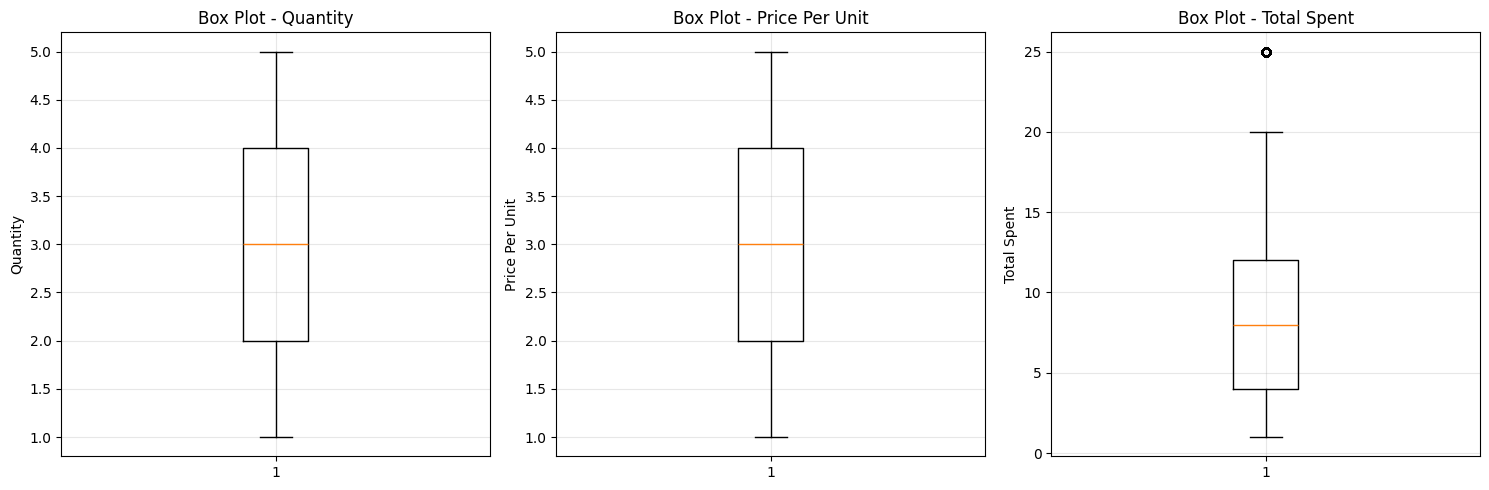

In [21]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Box Plot - {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

####    Step 10.2: Detecting Outliers 

In [22]:
# Define numeric columns
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

# Store outlier info
outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

    print(f"{col}:")
    print(f"  Lower Bound: {lower:.2f}")
    print(f"  Upper Bound: {upper:.2f}")
    print(f"  Outliers: {len(outliers)}")
    print()

# Check if any outliers exist
total_outliers = sum(outlier_counts.values())
if total_outliers == 0:
    print("No outliers found in any column!")
else:
    print(f"Total outliers: {total_outliers}")


Quantity:
  Lower Bound: -1.00
  Upper Bound: 7.00
  Outliers: 0

Price Per Unit:
  Lower Bound: -1.00
  Upper Bound: 7.00
  Outliers: 0

Total Spent:
  Lower Bound: -8.00
  Upper Bound: 24.00
  Outliers: 259

Total outliers: 259


#### Step 10.3: Removing Outliers

In [23]:
df_clean = df.copy()

Q1 = df_clean['Total Spent'].quantile(0.25)
Q3 = df_clean['Total Spent'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['Total Spent'] >= lower) & (df_clean['Total Spent'] <= upper)]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")
print(f"Removed rows: {len(df) - len(df_clean)}")

Original rows: 10000
Rows after removing outliers: 9741
Removed rows: 259


#### Step 10.4: Cap Total Spent at Upper bound

In [24]:
df_capped = df.copy()
df_capped['Total Spent'] = df_capped['Total Spent'].clip(upper=upper)

print(f"Max Total Spent after capping: {df_capped['Total Spent'].max()}")
print(f"Rows affected: {len(df[df['Total Spent'] > upper])}")

Max Total Spent after capping: 24.0
Rows affected: 259


#### Step 10.5 : Comparing Before and After

In [25]:
print("Before removing outliers:")
print(df['Total Spent'].describe())

print("\nAfter removing outliers:")
print(df_clean['Total Spent'].describe())

print("\nAfter capping outliers:")
print(df_capped['Total Spent'].describe())

Before removing outliers:
count    10000.00000
mean         8.87795
std          5.86059
min          1.00000
25%          4.00000
50%          8.00000
75%         12.00000
max         25.00000
Name: Total Spent, dtype: float64

After removing outliers:
count    9741.000000
mean        8.449287
std         5.307016
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        20.000000
Name: Total Spent, dtype: float64

After capping outliers:
count    10000.000000
mean         8.852050
std          5.791074
min          1.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         24.000000
Name: Total Spent, dtype: float64


### Step 11:Final Data Validation

In [26]:
# 1. Check missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "No missing values found!")

# 2. Check data types
print("\n2. Data Types Check:")
print(df.dtypes)

# 3. Check dataset shape
print(f"\n3. Dataset Shape: {df.shape}")
print(f"   Total Records: {df.shape[0]}")
print(f"   Total Columns: {df.shape[1]}")

# 4. Check all columns
print("\n4. All Columns in Dataset:")
print(df.columns.tolist())

# 5. Check for duplicates
print(f"\n5. Duplicate Check:")
print(f"   Duplicate Rows: {df.duplicated().sum()}")

# 6. Sample data
print("\n6. Sample Data (First 5 Rows):")
print(df.head())

# 7. Summary statistics
print("\n7. Summary Statistics for Numeric Columns:")
print(df.describe())

# 8. Save to Data folder (relative path)
df.to_csv("../../Data/Cleaned_cafe_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")
print(f"Location: ../Data/Cleaned_cafe_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")



1. Missing Values Check:
No missing values found!

2. Data Types Check:
Transaction ID                  str
Item                            str
Quantity                    float64
Price Per Unit              float64
Total Spent                 float64
Payment Method                  str
Location                        str
Transaction Date     datetime64[us]
Day_of_Week                     str
Transaction size           category
Item Category                   str
Price Category             category
Quantity Category          category
dtype: object

3. Dataset Shape: (10000, 13)
   Total Records: 10000
   Total Columns: 13

4. All Columns in Dataset:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Day_of_Week', 'Transaction size', 'Item Category', 'Price Category', 'Quantity Category']

5. Duplicate Check:
   Duplicate Rows: 0

6. Sample Data (First 5 Rows):
  Transaction ID    Item  Quantity  Price Per Unit  To

### Step 12: Define X and Y for Final Analysis

In [27]:
X=df.drop(['Transaction ID'],axis=1)
Y=df['Total Spent']
print(f"X Shape:{X.shape}")
print(f"Y Shape :{Y.shape}")

X Shape:(10000, 12)
Y Shape :(10000,)


## Step 13: Exploratory Data Analysis (EDA)

### 13.1: Item Analysis

In [28]:
# Top 10 selling items
print("="*60)
print("Top 10 Sellling Items:")
print("="*60)
print(df['Item'].value_counts().head(10))
print("="*60)
# Top 10 Revenue Generating Item
print("Top 10 Revenue Generating Items:")
print("="*60)
print(df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10))
print("="*60)
# Average Price by Item
print("Average Price By Item :")
print("="*60)
print(df.groupby('Item')['Price Per Unit'].mean().sort_values(ascending=False).head(10))
# Average Quantity by Item
print("="*60)
print("Average Quantity by Item:")
print("="*60)
print(df.groupby("Item")["Quantity"].mean().sort_values(ascending=False).head(10))

Top 10 Sellling Items:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: count, dtype: int64
Top 10 Revenue Generating Items:
Item
Salad       17021.0
Sandwich    13484.0
Smoothie    13132.0
Juice       10432.0
Cake        10341.0
Unknown      8540.0
Coffee       7184.0
Tea          5119.5
Cookie       3526.0
Name: Total Spent, dtype: float64
Average Price By Item :
Item
Salad       4.885017
Sandwich    3.956676
Smoothie    3.945255
Cake        3.000000
Juice       3.000000
Unknown     2.937049
Coffee      2.048927
Tea         1.590909
Cookie      1.120879
Name: Price Per Unit, dtype: float64
Average Quantity by Item:
Item
Smoothie    3.059307
Coffee      3.048069
Tea         3.047750
Cake        3.043898
Sandwich    3.030946
Salad       3.021777
Unknown     3.014448
Juice       3.000854
Cookie      2.975275
Name: Quantity, dtype: float64


### Step 13.2: Location Analysis

In [29]:
print("Location Distribution :")
print("="*60)
print(df["Location"].value_counts())
print("Distribution Percentage :")
print("="*60)
print(df["Location"].value_counts(normalize=True)*100)
print("\nRevenue by Location:")
print("="*60)
print(df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False))
print("\nTop 5 Items by Location:")
print("="*60)
print(pd.crosstab(df['Item'], df['Location']).head())

Location Distribution :
Location
Unknown     3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64
Distribution Percentage :
Location
Unknown     39.61
Takeaway    30.22
In-store    30.17
Name: proportion, dtype: float64

Revenue by Location:
Location
Unknown     35260.0
In-store    27090.0
Takeaway    26429.5
Name: Total Spent, dtype: float64

Top 5 Items by Location:
Location  In-store  Takeaway  Unknown
Item                                 
Cake           321       343      475
Coffee         318       351      496
Cookie         332       362      398
Juice          361       341      469
Salad          371       343      434


### Step 13.3: Payment Method Analysis

In [30]:
print("Payment Method Distribution : ")
print("="*60)
print(df["Payment Method"].value_counts())
print("="*60)
print("Revenue by Payemnt Method :")
print(df.groupby("Payment Method")['Total Spent'].sum().sort_values(ascending=False))
print("="*60)
print("Average Spend by Payemnt Method :")
print(df.groupby("Payment Method")["Total Spent"].mean().sort_values(ascending=False))

Payment Method Distribution : 
Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64
Revenue by Payemnt Method :
Payment Method
Unknown           27620.5
Credit Card       20415.0
Digital Wallet    20410.0
Cash              20334.0
Name: Total Spent, dtype: float64
Average Spend by Payemnt Method :
Payment Method
Cash              9.005314
Credit Card       8.981522
Digital Wallet    8.908773
Unknown           8.691158
Name: Total Spent, dtype: float64


### Step 13.4: Time Analysis

In [31]:
print("Sales Of Week :")
print("="*60)
print(df.groupby("Day_of_Week")["Total Spent"].sum().sort_values(ascending=False))
print("="*60)
print("Transaction of day of week :")
print(df["Day_of_Week"].value_counts())
print("="*60)
print("Average spend by Day of Week :")
print(df.groupby("Day_of_Week")["Total Spent"].mean().sort_values(ascending=False))
print("="*60)
df['Weekend'] = df['Day_of_Week'].apply(lambda x: 'Yes' if x in ['Saturday', 'Sunday'] else 'No')
print(df[['Day_of_Week', 'Weekend']].head())
print("\nWeekend Distribution:")
print("="*60)
print(df['Weekend'].value_counts())
print("="*60)
print("Weekend vs Weekdays")
weekend_sales = df[df['Weekend'] == 'Yes']['Total Spent'].sum()
weekday_sales = df[df['Weekend'] == 'No']['Total Spent'].sum()
print("="*60)
print(f"\nWeekend Sales: {weekend_sales:.2f}")
print(f"Weekday Sales: {weekday_sales:.2f}")
print(f"Weekend % of Total: {(weekend_sales/(weekend_sales+weekday_sales))*100:.1f}%")

Sales Of Week :
Day_of_Week
Monday       16332.5
Thursday     12362.5
Friday       12264.0
Sunday       12246.5
Saturday     11976.0
Tuesday      11957.0
Wednesday    11641.0
Name: Total Spent, dtype: float64
Transaction of day of week :
Day_of_Week
Monday       1842
Friday       1388
Thursday     1380
Sunday       1380
Saturday     1358
Wednesday    1341
Tuesday      1311
Name: count, dtype: int64
Average spend by Day of Week :
Day_of_Week
Tuesday      9.120519
Thursday     8.958333
Sunday       8.874275
Monday       8.866721
Friday       8.835735
Saturday     8.818851
Wednesday    8.680835
Name: Total Spent, dtype: float64
  Day_of_Week Weekend
0      Friday      No
1     Tuesday      No
2   Wednesday      No
3    Thursday      No
4      Sunday     Yes

Weekend Distribution:
Weekend
No     7262
Yes    2738
Name: count, dtype: int64
Weekend vs Weekdays

Weekend Sales: 24222.50
Weekday Sales: 64557.00
Weekend % of Total: 27.3%


### Step 13.5: Category Analysis

In [32]:
print("Item Category Distribution:")
print("="*60)
print(df['Item Category'].value_counts())
print("Revenue by Item Category:")
print("="*60)
print(df.groupby('Item Category')['Total Spent'].sum().sort_values(ascending=False))
print("Price Category Distribution:")
print("="*60)
print(df['Price Category'].value_counts())
print("Transaction Size Distribution:")
print(df['Transaction size'].value_counts())
print("Quantity Category Distribution:")
print(df['Quantity Category'].value_counts())

Item Category Distribution:
Item Category
Beverage    4521
Food        2279
Bakery      2231
Unknown      969
Name: count, dtype: int64
Revenue by Item Category:
Item Category
Beverage    35867.5
Food        30505.0
Bakery      13867.0
Unknown      8540.0
Name: Total Spent, dtype: float64
Price Category Distribution:
Price Category
High      3535
Low       3503
Medium    2962
Name: count, dtype: int64
Transaction Size Distribution:
Transaction size
Very small    3480
Small         3398
Medium        1673
Large         1190
Very large     259
Name: count, dtype: int64
Quantity Category Distribution:
Quantity Category
high      3876
medium    2328
Small     1974
single    1822
Name: count, dtype: int64


### Step 13.6:Cross Analysis

In [33]:
print("Item Category by Location:")
print("="*60)
print(pd.crosstab(df['Item Category'], df['Location']))
print("Price Category by Location:")
print("="*60)
print(pd.crosstab(df['Price Category'], df['Location']))
print("Item Category by Payment Method:")
print("="*60)
print(pd.crosstab(df['Item Category'], df['Payment Method']))
print("Transaction Size by Location:")
print("="*60)
print(pd.crosstab(df['Transaction size'], df['Location']))

Item Category by Location:
Location       In-store  Takeaway  Unknown
Item Category                             
Bakery              653       705      873
Beverage           1329      1332     1860
Food                741       688      850
Unknown             294       297      378
Price Category by Location:
Location        In-store  Takeaway  Unknown
Price Category                             
Low                 1032      1104     1367
Medium               881       879     1202
High                1104      1039     1392
Item Category by Payment Method:
Payment Method  Cash  Credit Card  Digital Wallet  Unknown
Item Category                                             
Bakery           521          506             511      693
Beverage         987         1002            1059     1473
Food             538          535             495      711
Unknown          212          230             226      301
Transaction Size by Location:
Location          In-store  Takeaway  Unknown
Tran

### Step 13.7: Correlation Anlaysis

In [34]:
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
correlation = df[numeric_cols].corr()
print("\nCorrelation Matrix:")
print(correlation)
print("\nCorrelation with Total Spent:")
print(correlation['Total Spent'].sort_values(ascending=False))


Correlation Matrix:
                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.005913     0.668821
Price Per Unit  0.005913        1.000000     0.612374
Total Spent     0.668821        0.612374     1.000000

Correlation with Total Spent:
Total Spent       1.000000
Quantity          0.668821
Price Per Unit    0.612374
Name: Total Spent, dtype: float64


### Step 13.8: Summary Statistics

In [35]:
print("Total Revenue: {:.2f}".format(df['Total Spent'].sum()))
print("Total Transactions: {}".format(len(df)))
print("Average Transaction Value: {:.2f}".format(df['Total Spent'].mean()))
print("Max Transaction Value: {:.2f}".format(df['Total Spent'].max()))
print("Min Transaction Value: {:.2f}".format(df['Total Spent'].min()))

print("Top 3 Best Selling Items:")
print(df['Item'].value_counts().head(3))

print("Top 3 Revenue Generating Items:")
print(df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(3))

print("Most Popular Payment Method:")
print(df['Payment Method'].value_counts().index[0])

print("Most Popular Location:")
print(df['Location'].value_counts().index[0])

Total Revenue: 88779.50
Total Transactions: 10000
Average Transaction Value: 8.88
Max Transaction Value: 25.00
Min Transaction Value: 1.00
Top 3 Best Selling Items:
Item
Juice     1171
Coffee    1165
Salad     1148
Name: count, dtype: int64
Top 3 Revenue Generating Items:
Item
Salad       17021.0
Sandwich    13484.0
Smoothie    13132.0
Name: Total Spent, dtype: float64
Most Popular Payment Method:
Unknown
Most Popular Location:
Unknown


## Step 14: Visualisation

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

visuals_dir = Path("../../Assets")
visuals_dir.mkdir(parents=True, exist_ok=True)


### Step 1: Revenue by Item

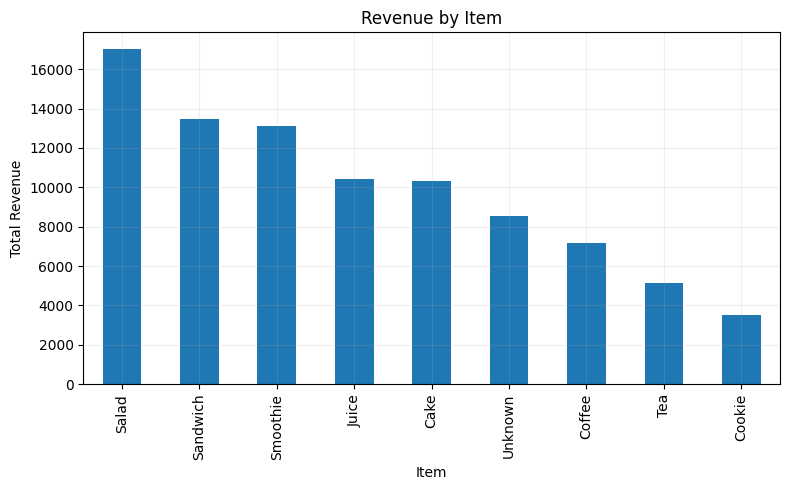

In [49]:
plt.figure(figsize=(8,5))
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).plot(kind='bar')
plt.ylabel("Total Revenue")
plt.title("Revenue by Item")
plt.tight_layout()
plt.grid(alpha=.2)
plt.savefig(
    visuals_dir / "Revenue by Item.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Step 14.2: Weekend vs Weekdays

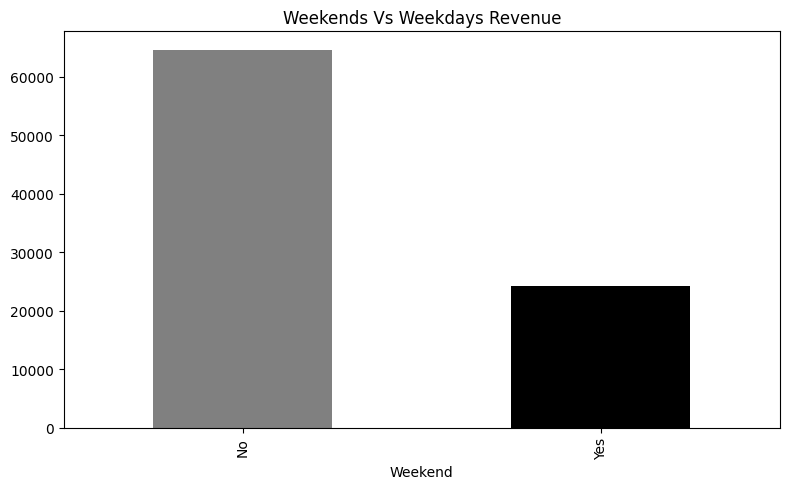

In [51]:
plt.figure(figsize=(8,5))
df.groupby("Weekend")["Total Spent"].sum().sort_values(ascending=False).plot(kind='bar',color=['grey','black'])
plt.title("Weekends Vs Weekdays Revenue")
plt.tight_layout()
plt.savefig(
    visuals_dir /"Weekend Vs Weekdays Revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Step 14.3: Correlation Heatmap

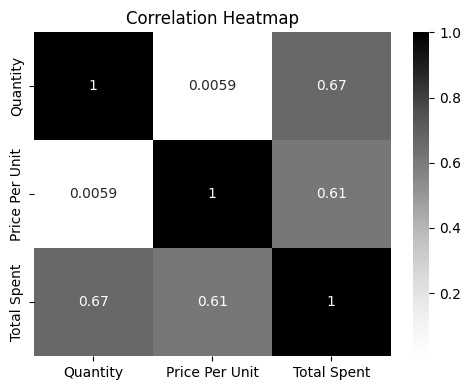

In [52]:
plt.figure(figsize=(5,4))
sns.heatmap(df[['Quantity','Price Per Unit','Total Spent']].corr(),annot=True,cmap='Greys')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    visuals_dir/"Correlation Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Step 14.4: Category Revenue share

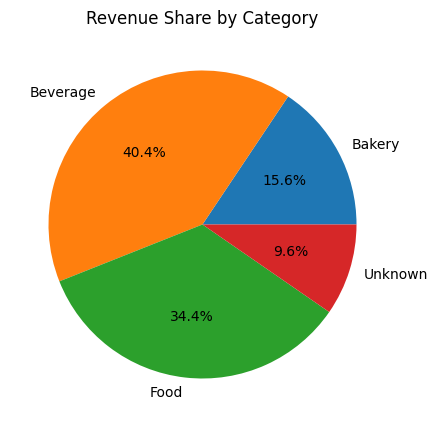

In [54]:
plt.figure(figsize=(6,5))
df.groupby("Item Category")["Total Spent"].sum().plot(kind='pie',autopct='%1.1f%%')
plt.title('Revenue Share by Category'); plt.ylabel('')
plt.savefig(
    visuals_dir/"Revenue Share by Category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Step 14.5: Sales trend by Day of Week

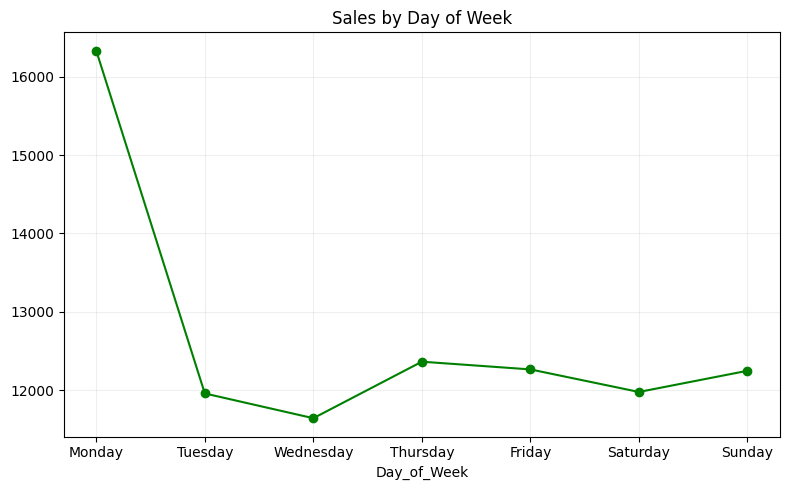

In [55]:
plt.figure(figsize=(8,5))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('Day_of_Week')['Total Spent'].sum().reindex(order).plot(kind='line',color='green', marker
='o')
plt.title('Sales by Day of Week'); plt.tight_layout()
plt.grid(alpha=.2)

plt.savefig(
    visuals_dir/"Sales by Day of Week.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Step 15: Call Out the 'Unknown' Data Quality Issue

In [42]:
unknown_pct = (df['Location'] == 'Unknown').mean() * 100
print(f"Location missing/unknown: {unknown_pct:.1f}% of all transactions")

Location missing/unknown: 39.6% of all transactions


## Key Business Insights
- Salad generates the most revenue (Rs 17,069) despite Juice having more transactions
—
price per unit matters more than volume here
- Weekday revenue (Rs 64,897) far outpaces weekend revenue (Rs 24,346)
- ~40% of transactions have no recorded Location — a data-capture gap worth fixing at
the POS
- Quantity and Price Per Unit are both moderately correlated with Total Spent (0.67 an
d 0.61)
- Average transaction value is Rs 8.92 across 10,000 transactions
